## Load the tokenizer

In [1]:
import sys
sys.path.append('..')

In [2]:
from minbpe import BasicTokenizer

tokenizer = BasicTokenizer()
tokenizer.load(model_file="../output/tokenizer/my_tokenizer.model")


def get_vocab_size(tokenizer: BasicTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

## Create the model

In [3]:
import torch
torch.manual_seed(3647)
torch.set_float32_matmul_precision('high')
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = 'cuda:1' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'

In [4]:
from variant_gpt.models import GPT2Config, GPT2Model

config = GPT2Config(
    vocab_size=get_vocab_size(tokenizer),
    dropout=0.15,
    device=device,
    flash=True
)

model = GPT2Model(config)
model = torch.compile(model)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

number of parameters: 85.75M
86.5344 M parameters


## Data preparation

### 1. Load the data

In [5]:
import os
import pickle

text_path = "../output/combined_text.txt"
encoded_path = "../output/encoded_text.pkl"

if os.path.exists(encoded_path):
    print("Loading encoded sequence from file...")
    with open(encoded_path, "rb") as f:
        encoded_text_sequence = pickle.load(f)
else:
    print("Encoding text...")
    with open(text_path, "r", encoding="utf-8") as f:
        text_sequence = f.read()

    encoded_text_sequence = tokenizer.encode(text_sequence)

    print("Saving encoded sequence to file...")
    with open(encoded_path, "wb") as f:
        pickle.dump(encoded_text_sequence, f)

print(f"Length of encoded sequence: {len(encoded_text_sequence)}")

Loading encoded sequence from file...
Length of encoded sequence: 816962


### 2. Split it into train and test

In [6]:
data = torch.tensor(encoded_text_sequence, dtype=torch.long)
split_index = int(0.9*len(data))
train_data = data[:split_index]
val_data = data[split_index:]

### 3. Data loader

In [7]:
from typing import Tuple

batch_size = 96

def get_batch(split: str, block_size: int, batch_size: int, device) -> Tuple[torch.Tensor, torch.Tensor]:
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    index = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in index])
    y = torch.stack([data[i+1:i+block_size+1] for i in index])
    x, y = x.to(device), y.to(device)
    return x, y

In [8]:
x, y = get_batch('train', config.block_size, batch_size, config.device)
x.shape, y.shape

(torch.Size([96, 1024]), torch.Size([96, 1024]))

### 4. Training

In [9]:
from typing import Dict


@torch.no_grad()
def estimate_loss(
        model: torch.nn.Module,
        eval_iters: int,
        batch_size: int
) -> Dict:
    was_training = model.training
    model.eval()

    results: Dict[str, float] = {}
    device = config.device

    for split_name in ['train', 'val']:
        losses = []

        for k in range(eval_iters):
            x, y = get_batch(split_name, config.block_size, batch_size, device)

            # Expecting model to return (logits, loss)
            with torch.autocast(device_type, dtype=torch.bfloat16):
                _, loss = model(x, y)
            losses.append(loss.item())

        results[split_name] = float(torch.tensor(losses).mean())

    if was_training:
        model.train()

    return results

In [10]:
class EarlyStopping:
    def __init__(self, patience: int = 5, min_delta: float = 1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best_val_loss = float('inf')
        self.stale_count = 0

    @property
    def should_stop(self) -> bool:
        return self.stale_count >= self.patience

    def step(self, val_loss: float) -> bool:
        """Update state. Returns True if this is a new best."""
        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.stale_count = 0
            return True
        self.stale_count += 1
        return False

In [11]:
import os

class CheckpointManager:
    """Keeps the last `keep_last` periodic checkpoints plus the single best."""

    @staticmethod
    def _save_checkpoint(
            model: GPT2Model,
            optimizer: torch.optim.Optimizer,
            epoch: int,
            loss: float,
            file_path: str = "checkpoint.pth"
    ) -> None:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss
        }
        torch.save(checkpoint, file_path)

    def __init__(self, checkpoint_dir: str, keep_last: int = 3):
        self.checkpoint_dir = checkpoint_dir
        self.keep_last = keep_last
        self._periodic: list[str] = []   # ordered oldest → newest
        self._best: str | None = None

    def save_periodic(self, model, optimizer, epoch, loss, batch_idx) -> str:
        path = os.path.join(self.checkpoint_dir, f"checkpoint_{epoch}_{batch_idx}.pth")
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._periodic.append(path)
        self._evict_old()
        return path

    def save_epoch(self, model, optimizer, epoch, loss) -> str:
        path = os.path.join(self.checkpoint_dir, f"checkpoint_{epoch}.pth")
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._periodic.append(path)
        self._evict_old()
        return path

    def save_best(self, model, optimizer, epoch, loss) -> str:
        path = os.path.join(self.checkpoint_dir, "checkpoint_best.pth")
        if self._best:
            os.remove(self._best)
        self._save_checkpoint(model=model, optimizer=optimizer, epoch=epoch, loss=loss, file_path=path)
        self._best = path
        return path

    def _evict_old(self):
        """Delete periodic checkpoints beyond the keep_last window."""
        while len(self._periodic) > self.keep_last:
            oldest = self._periodic.pop(0)
            if oldest != self._best and os.path.exists(oldest):
                os.remove(oldest)

In [12]:
env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [13]:
import os
from tqdm.notebook import tqdm

# ── Hyperparameters ────────────────────────────────────────────────────────────
num_epochs       = 2
steps_per_epoch  = 7649
max_iters        = num_epochs * steps_per_epoch
eval_interval    = 200          # steps between evaluations
eval_iters       = 200          # batches sampled for loss estimate
grad_clip        = 1.0          # max gradient norm; prevents exploding gradients

early_stopping = EarlyStopping(patience=5, min_delta=1e-4)

# ── Optimizer + scheduler ──────────────────────────────────────────────────────
weight_decay = 1e-1
learning_rate  = 1e-5
beta1 = 0.9
beta2 = 0.95
optimizer = model.configure_optimizers(weight_decay, learning_rate, (beta1, beta2), device_type)

# Cosine annealing decays LR smoothly over training; last_epoch=-1 starts fresh.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_iters, eta_min=learning_rate * 0.1)

# ── History ────────────────────────────────────────────────────────────────────
train_losses = []
val_losses = []

# ── Training ───────────────────────────────────────────────────────────────────
CHECKPOINT_DIR = "../output/pre_training/run_4_2"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

ckpt_manager = CheckpointManager(CHECKPOINT_DIR, keep_last=3)

model.train()
for epoch in range(num_epochs):
    progress_bar = tqdm(
        range(steps_per_epoch),
        total=steps_per_epoch,
        desc=f"Epoch {epoch + 1}/{num_epochs}"
    )

    for step in progress_bar:
        iteration = epoch * steps_per_epoch + step  # global step count

        x_batch, y_batch = get_batch('train', config.block_size, batch_size, config.device)

        # Training step
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type, dtype=torch.bfloat16):
            logits, loss = model(x_batch, y_batch)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix({
            "lr":    f"{scheduler.get_last_lr()[0]:.2e}",
            "stale": f"{early_stopping.stale_count}/{early_stopping.patience}"
        })

        # ── Periodic evaluation ────────────────────────────────────────────
        is_eval_step  = step > 0 and step % eval_interval == 0
        is_final_step = step == steps_per_epoch - 1

        if is_eval_step or is_final_step:
            losses = estimate_loss(
                model=model,
                eval_iters=eval_iters,
                batch_size=batch_size
            )
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])

            tqdm.write(
                f"[Epoch {epoch + 1} | Step {step:>5d}] "
                f"Train: {losses['train']:.4f} | "
                f"Val:   {losses['val']:.4f} | "
                f"LR: {scheduler.get_last_lr()[0]:.2e}"
            )

            # ── Early stopping + best-model checkpoint ─────────────────────
            if early_stopping.step(losses['val']):
                tqdm.write(f"  ✅ New best val loss: {early_stopping.best_val_loss:.4f}")
                ckpt_manager.save_best(
                    model=model, optimizer=optimizer,
                    epoch=epoch, loss=losses['val']
                )
            else:
                tqdm.write(f"  ⚠️  Stale eval {early_stopping.stale_count}/{early_stopping.patience}")

            # ── Periodic snapshot ──────────────────────────────────────────
            if is_eval_step:
                ckpt_manager.save_periodic(
                    model=model, optimizer=optimizer,
                    epoch=iteration, loss=losses['val'],
                    batch_idx=step
                )

            if early_stopping.should_stop:
                break

    if early_stopping.should_stop:
        tqdm.write(f"\n🛑 Early stopping triggered — no improvement for {early_stopping.patience} evaluations.")
        break

    # End-of-epoch snapshot
    last_val = val_losses[-1] if val_losses else float("nan")
    ckpt_manager.save_epoch(
        model=model, optimizer=optimizer,
        epoch=epoch, loss=last_val
    )

tqdm.write("\nTraining completed ✅")

num decayed parameter tensors: 50, with 86,515,200 parameters
num non-decayed parameter tensors: 25, with 19,200 parameters
using fused AdamW: True


Epoch 1/2:   0%|          | 0/7649 [00:00<?, ?it/s]

[Epoch 1 | Step   200] Train: 5.3364 | Val:   5.3827 | LR: 1.00e-05
  ✅ New best val loss: 5.3827
[Epoch 1 | Step   400] Train: 4.8022 | Val:   4.8606 | LR: 9.98e-06
  ✅ New best val loss: 4.8606
[Epoch 1 | Step   600] Train: 4.5739 | Val:   4.6504 | LR: 9.97e-06
  ✅ New best val loss: 4.6504
[Epoch 1 | Step   800] Train: 4.4537 | Val:   4.5420 | LR: 9.94e-06
  ✅ New best val loss: 4.5420
[Epoch 1 | Step  1000] Train: 4.3731 | Val:   4.4762 | LR: 9.91e-06
  ✅ New best val loss: 4.4762
[Epoch 1 | Step  1200] Train: 4.3154 | Val:   4.4363 | LR: 9.86e-06
  ✅ New best val loss: 4.4363
[Epoch 1 | Step  1400] Train: 4.2737 | Val:   4.4057 | LR: 9.82e-06
  ✅ New best val loss: 4.4057
[Epoch 1 | Step  1600] Train: 4.2325 | Val:   4.3823 | LR: 9.76e-06
  ✅ New best val loss: 4.3823
[Epoch 1 | Step  1800] Train: 4.1955 | Val:   4.3642 | LR: 9.70e-06
  ✅ New best val loss: 4.3642
[Epoch 1 | Step  2000] Train: 4.1679 | Val:   4.3434 | LR: 9.63e-06
  ✅ New best val loss: 4.3434
[Epoch 1 | Step  220

Epoch 2/2:   0%|          | 0/7649 [00:00<?, ?it/s]

[Epoch 2 | Step   200] Train: 3.1016 | Val:   3.9593 | LR: 5.31e-06
  ✅ New best val loss: 3.9593
[Epoch 2 | Step   400] Train: 3.0784 | Val:   3.9511 | LR: 5.13e-06
  ✅ New best val loss: 3.9511
[Epoch 2 | Step   600] Train: 3.0358 | Val:   3.9431 | LR: 4.95e-06
  ✅ New best val loss: 3.9431
[Epoch 2 | Step   800] Train: 2.9942 | Val:   3.9412 | LR: 4.76e-06
  ✅ New best val loss: 3.9412
[Epoch 2 | Step  1000] Train: 2.9655 | Val:   3.9349 | LR: 4.58e-06
  ✅ New best val loss: 3.9349
[Epoch 2 | Step  1200] Train: 2.9328 | Val:   3.9327 | LR: 4.40e-06
  ✅ New best val loss: 3.9327
[Epoch 2 | Step  1400] Train: 2.9075 | Val:   3.9310 | LR: 4.22e-06
  ✅ New best val loss: 3.9310
[Epoch 2 | Step  1600] Train: 2.8851 | Val:   3.9292 | LR: 4.05e-06
  ✅ New best val loss: 3.9292
[Epoch 2 | Step  1800] Train: 2.8505 | Val:   3.9254 | LR: 3.87e-06
  ✅ New best val loss: 3.9254
[Epoch 2 | Step  2000] Train: 2.8255 | Val:   3.9263 | LR: 3.70e-06
  ⚠️  Stale eval 1/5
[Epoch 2 | Step  2200] Train:

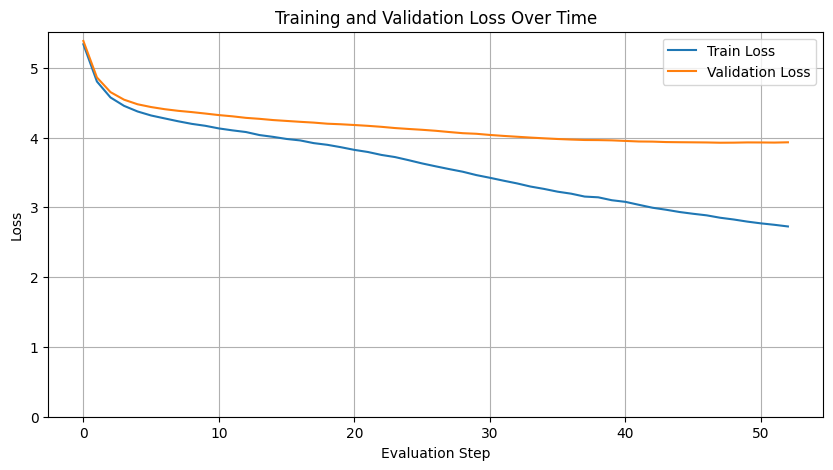

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [15]:
input_tokens = tokenizer.encode("Buongiorno ")
input_tokens = torch.tensor(
    input_tokens, dtype=torch.long).unsqueeze(0).to(config.device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

Buongiorno a tutti a casahahahaahaha ti sirato che Totti si vince il mio compleanno ho punato 800 paci Ami ricordati il diviso della partita l'ademia inima so abbiamo ragione Ahahahahahahaha profonato una caspò una volta già lettato che non era si vincenerli in Attaccia se lo fate piudesso L'ha detto anche 
